In [2]:
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(future))
suppressMessages(library(parallel))
suppressMessages(library(RColorBrewer))
suppressMessages(library(viridis))
suppressMessages(library(qs))
suppressMessages(library(harmony))
suppressMessages(library(igraph))
suppressMessages(library(ggraph))
suppressMessages(library(ggrepel)) 
suppressMessages(library(tidyr))
suppressMessages(library(foreach))
suppressMessages(library(doParallel))
suppressMessages(library(tidygraph))
suppressMessages(library(anndata))
suppressMessages(library(randomForest))
suppressMessages(library(pheatmap))
suppressMessages(library(dbscan))
suppressMessages(library(scDblFinder))
suppressMessages(library(cowplot))

# Python 环境
suppressMessages(library(reticulate))
RETICULATE_PYTHON <- "/home/chaiqw/project/mb/.venv/bin/python"
use_virtualenv("/home/chaiqw/project/mb/.venv")

# 资源设定
plan("multicore", workers = 64)
options(future.globals.maxSize = 100000 * 1024^5)


In [3]:
seurat = readRDS('/mnt/90-connectome/Personal/CQW/midbrain/area_h5ad/20260728_VTA_SCTseurat_harmony_rf_clean.rds')

In [4]:
non_class = c( 'Astro', 'Oligo', 'Endotheial', 'OPC', 'Micro', 'VLMC')
seurat_non = subset(seurat, Class %in% non_class & nFeature_RNA > 800)
seurat_non

An object of class Seurat 
39743 features across 60696 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

In [5]:
seurat_non$Class <- as.character(seurat_non$Class)
seurat_non$Class[seurat_non$Class == "Endotheial"] <- "Endo"

Processing class: Astro; resolution: 0.05

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might 

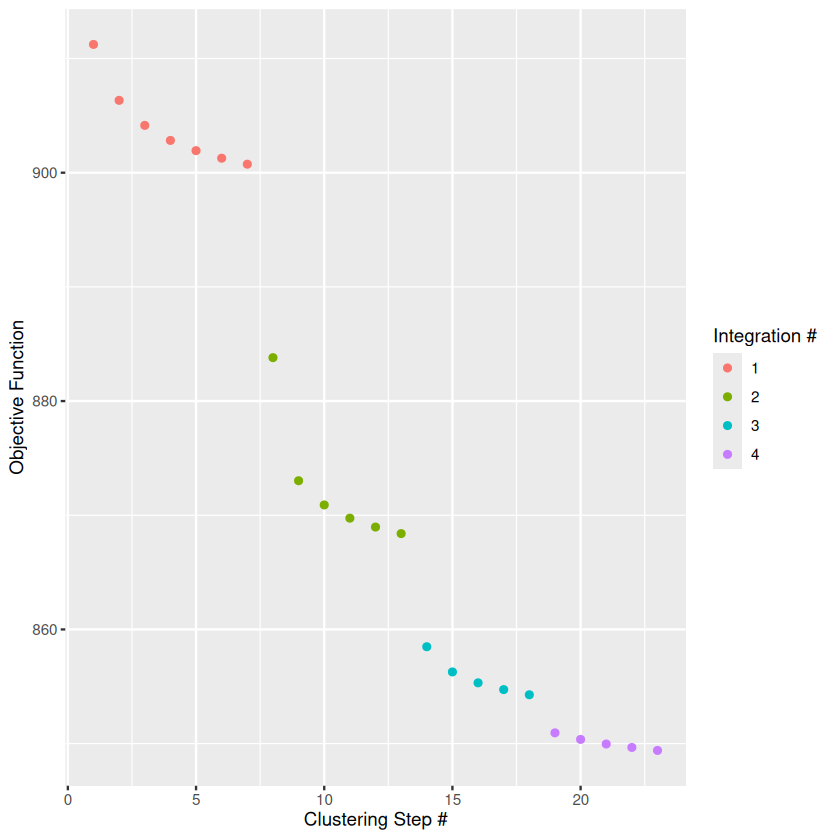

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:46:47 UMAP embedding parameters a = 0.9922 b = 1.112

01:46:47 Read 34198 rows and found 15 numeric columns

01:46:47 Using Annoy for neighbor search, n_neighbors = 30

01:46:47 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

0

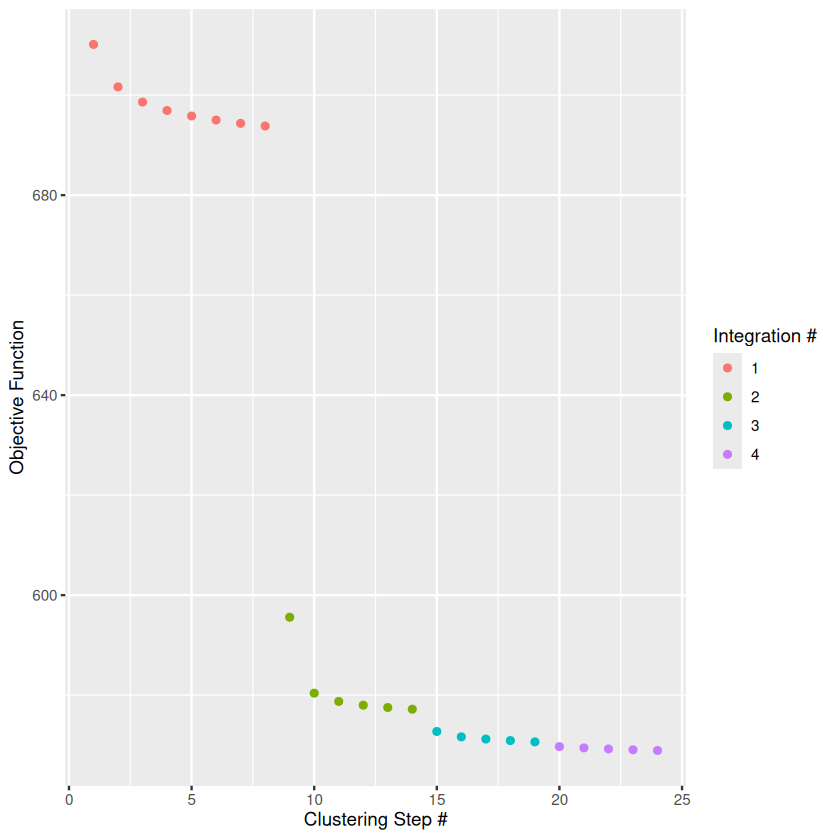

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:49:33 UMAP embedding parameters a = 0.9922 b = 1.112

01:49:33 Read 582 rows and found 15 numeric columns

01:49:33 Using Annoy for neighbor search, n_neighbors = 30

01:49:33 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01:

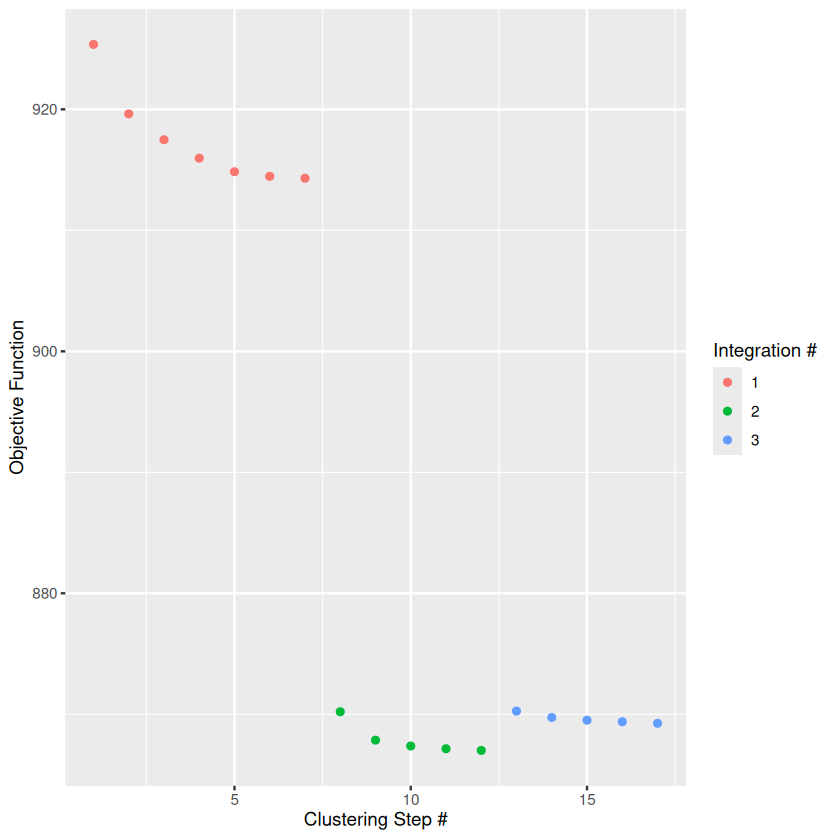

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:52:36 UMAP embedding parameters a = 0.9922 b = 1.112

01:52:36 Read 7881 rows and found 15 numeric columns

01:52:36 Using Annoy for neighbor search, n_neighbors = 30

01:52:36 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01

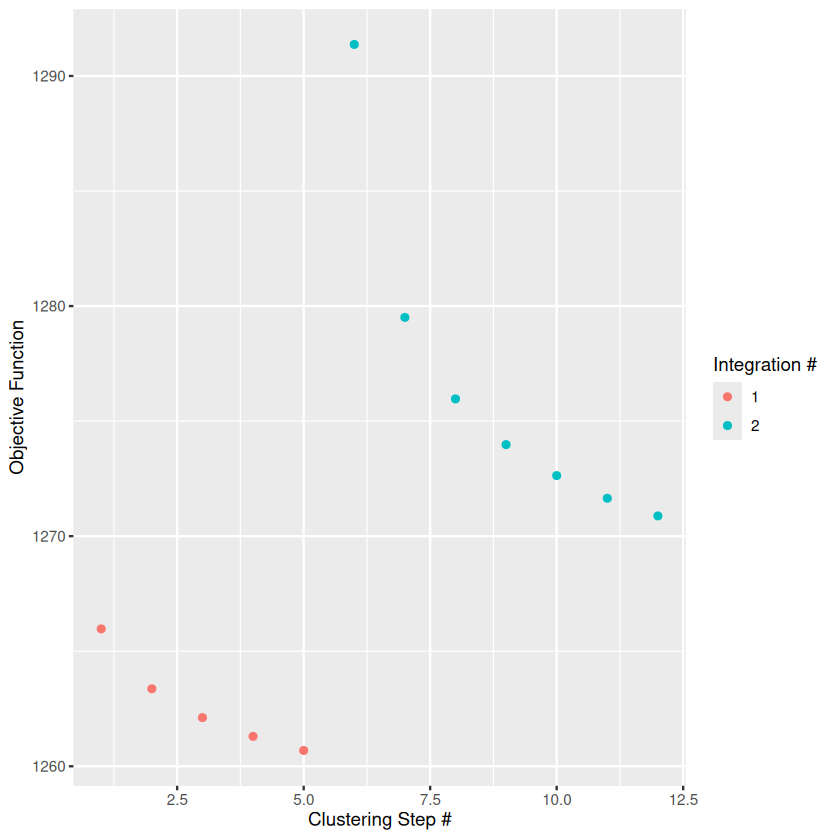

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:56:03 UMAP embedding parameters a = 0.9922 b = 1.112

01:56:03 Read 3932 rows and found 15 numeric columns

01:56:03 Using Annoy for neighbor search, n_neighbors = 30

01:56:03 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01

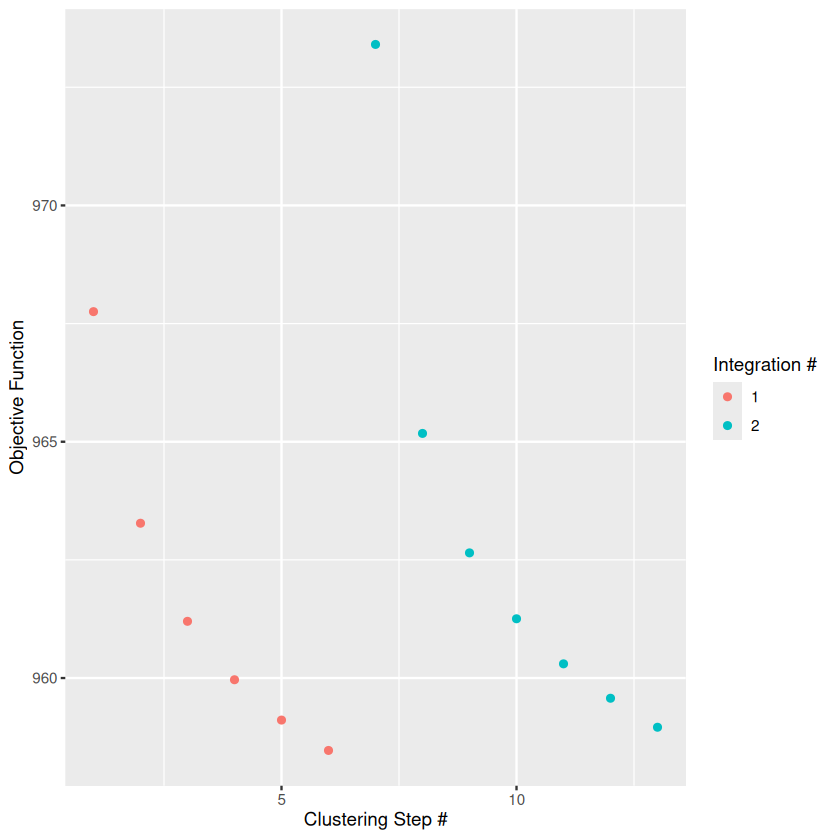

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
01:58:39 UMAP embedding parameters a = 0.9922 b = 1.112

01:58:39 Read 714 rows and found 15 numeric columns

01:58:39 Using Annoy for neighbor search, n_neighbors = 30

01:58:40 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

01:

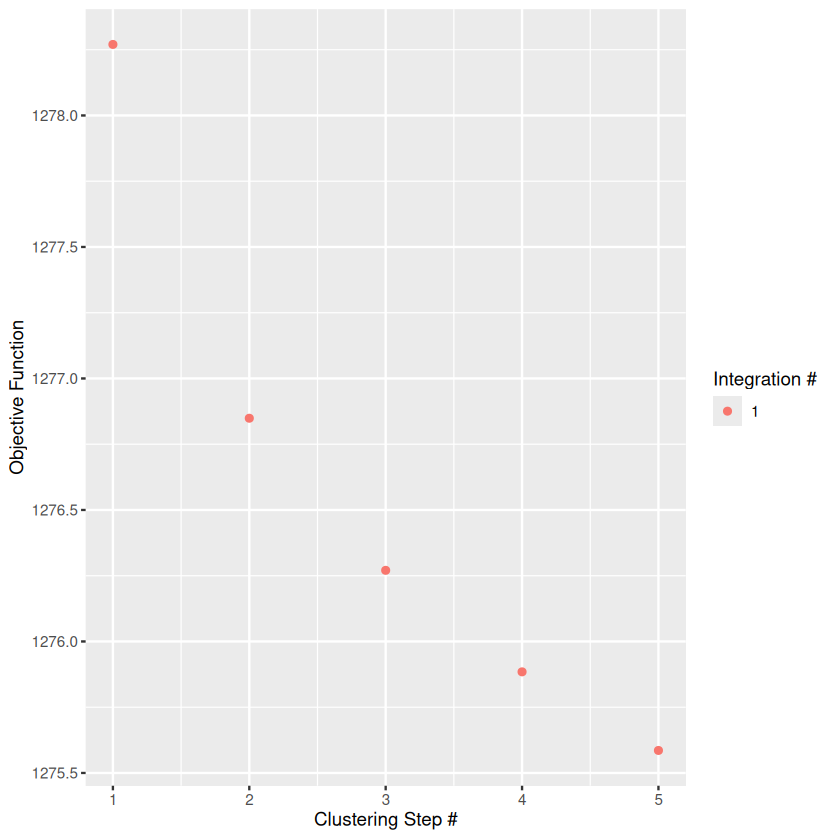

In [6]:
class_list = c( 'Astro', 'Oligo', 'Endo', 'OPC', 'Micro', 'VLMC')

# 按 class 设置聚类分辨率；可根据各类细胞的聚类结果继续调整
resolution_by_class = c(
    Astro = 0.05,
    Oligo = 0.05,
    Endo = 0.01,
    OPC = 0.03,
    Micro = 0.003,
    VLMC = 0.01
)

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

class_results = list()

for (class_name in class_list) {
    class_resolution = resolution_by_class[[class_name]]
    message("Processing class: ", class_name, "; resolution: ", class_resolution)

    sub = subset(seurat_non, Class == class_name)

    # 剔除线粒体基因
    assay = sub@assays$RNA$counts
    meta = sub@meta.data
    new_assay = assay[setdiff(rownames(assay), mt_gene), ]

    sub1 = CreateSeuratObject(counts = new_assay)
    sub1 = AddMetaData(sub1, meta)

    sub1 = NormalizeData(sub1, normalization.method = "LogNormalize", scale.factor = 10000)
    sub1 = FindVariableFeatures(sub1, selection.method = "vst", nfeatures = 3000)
    sub1 = ScaleData(sub1, features = rownames(sub1))

    sub1 = sub1 %>%
        RunPCA(npcs = 50, verbose = FALSE) %>%
        FindNeighbors(dims = 1:15) %>%
        FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
        RunUMAP(dims = 1:15, umap.method = "umap-learn")

    sub1 = RunHarmony(
        sub1, group.by.vars = "Animal", plot_convergence = TRUE,
        reduction.save = "harmony", dims.use = 1:15,
        theta = 2, verbose = FALSE 
    )

    sub1 = sub1 %>%
        FindNeighbors(reduction = "harmony", dims = 1:15) %>%
        FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
        RunUMAP(reduction = "harmony", dims = 1:15)

    class_results[[class_name]] = sub1
}

# 每个 class 的结果都在 class_results 中，例如：class_results[["Neuron"]]

### Non-neuron clustering

In [ ]:

class_results$Astro$cluster = paste0('Astro_', class_results$Astro$seurat_clusters)
class_results$Oligo$cluster = paste0('Oligo_', class_results$Oligo$seurat_clusters)
class_results$Micro$cluster = paste0('Micro_', class_results$Micro$seurat_clusters)
class_results$OPC$cluster = paste0('OPC_', class_results$OPC$seurat_clusters)
class_results$VLMC$cluster = paste0('VLMC_', class_results$VLMC$seurat_clusters)
class_results$Endo$cluster = paste0('Endo_', class_results$Endo$seurat_clusters)

In [8]:

sub3=class_results$Astro@meta.data[,'cluster',drop=F]
sub4=class_results$Oligo@meta.data[,'cluster',drop=F]
sub5=class_results$Micro@meta.data[,'cluster',drop=F]
sub6=class_results$OPC@meta.data[,'cluster',drop=F]
sub7=class_results$VLMC@meta.data[,'cluster',drop=F]
sub8=class_results$Endo@meta.data[,'cluster',drop=F]

sub=rbind(sub3,sub4,sub5,sub6,sub7,sub8)

In [9]:
#将新分类的结果添加到metadata中，并命名为subclass
seurat_non_1=AddMetaData(seurat_non,sub,col.name = 'cluster')
seurat_non_1
table(seurat_non_1$cluster)

An object of class Seurat 
39743 features across 60696 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony


Astro_0 Astro_1 Astro_2   Endo0   Endo1 Micro_0 Micro_1 Oligo_0 Oligo_1   OPC_0 
  12678     417     294     461     121    3670     262   31356    2842    7504 
  OPC_1   OPC_2  VLMC_0 
    198     179     714 

In [12]:
sampleRatio = 0.8
maxCell = 500
sampleDf = seurat_non_1@meta.data[, c("cluster"), drop=F]
sampleList = split(sampleDf, sampleDf$cluster)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$cluster )

trainSeurat = seurat_non_1[,rownames(sampleDf)]
table(trainSeurat$cluster)

'data.frame':	4542 obs. of  1 variable:
 $ cluster: chr  "Astro_0" "Astro_0" "Astro_0" "Astro_0" ...



Astro_0 Astro_1 Astro_2   Endo0   Endo1 Micro_0 Micro_1 Oligo_0 Oligo_1   OPC_0 
    500     333     235     368      96     500     209     500     500     500 
  OPC_1   OPC_2  VLMC_0 
    158     143     500 


Astro_0 Astro_1 Astro_2   Endo0   Endo1 Micro_0 Micro_1 Oligo_0 Oligo_1   OPC_0 
    500     333     235     368      96     500     209     500     500     500 
  OPC_1   OPC_2  VLMC_0 
    158     143     500 

In [13]:
Idents(trainSeurat) = "cluster"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)

Calculating cluster Oligo_1

Calculating cluster VLMC_0

Calculating cluster OPC_0

Calculating cluster Astro_2

Calculating cluster Micro_0

Calculating cluster Astro_1

Calculating cluster Oligo_0

Calculating cluster Astro_0

Calculating cluster Micro_1

Calculating cluster OPC_1

Calculating cluster Endo0

Calculating cluster OPC_2

Calculating cluster Endo1




Oligo_1  VLMC_0   OPC_0 Astro_2 Micro_0 Astro_1 Oligo_0 Astro_0 Micro_1   OPC_1 
   1321     620     796     938     858     843     468    1100     459     470 
  Endo0   OPC_2   Endo1 
   1622     583     821 

In [ ]:
trainSeurat@assays$SCT$data

An object of class Seurat 
39743 features across 3465 samples within 2 assays 
Active assay: SCT (19386 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, umap, harmony

In [14]:
trainDf = as.data.frame(t(as.matrix(trainSeurat@assays$SCT$data[unique(classMarker$gene), ])))
trainDf$cluster = trainSeurat$cluster
# trainDf = subset(trainDf, cluster != "Uncertain")
trainDf$cluster = factor(trainDf$cluster)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_cluster~., data=trainDf, ntree=300)

 num [1:13, 1:14] 500 12 82 0 0 0 0 0 0 0 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:13] "Astro_0" "Astro_1" "Astro_2" "Endo0" ...
  ..$ : chr [1:14] "Astro_0" "Astro_1" "Astro_2" "Endo0" ...


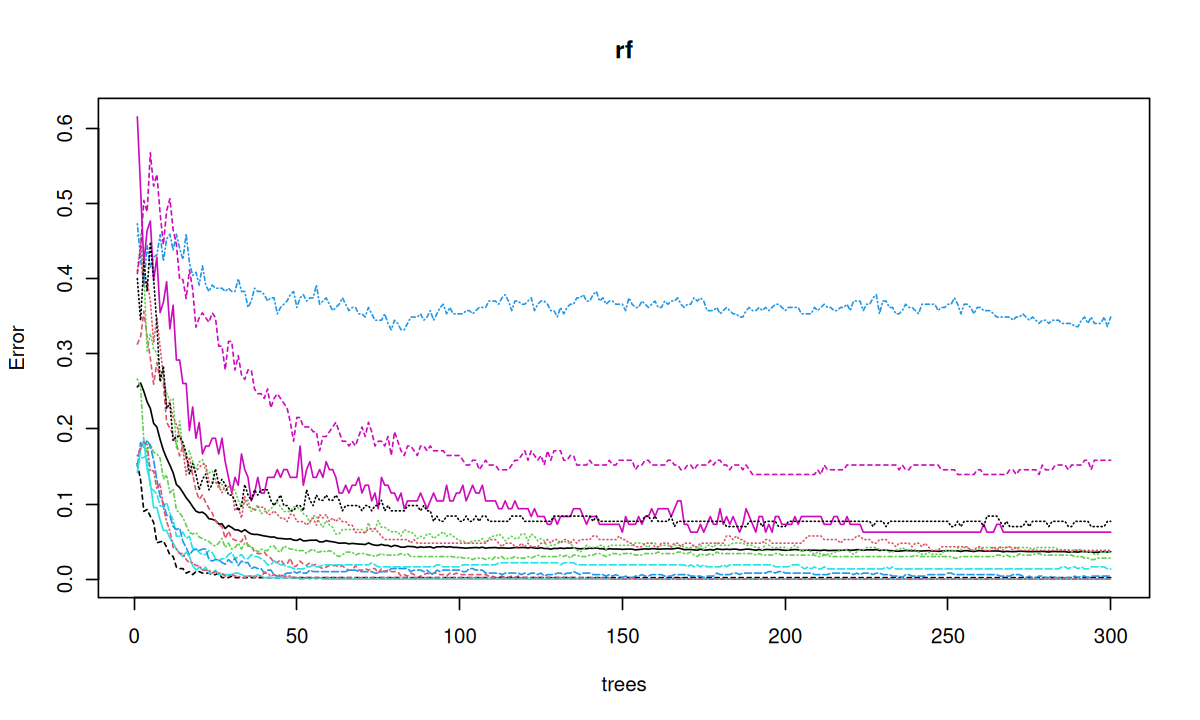

In [15]:
str(rf$confusion)
options(repr.plot.width=10, repr.plot.height=6)
plot(rf)


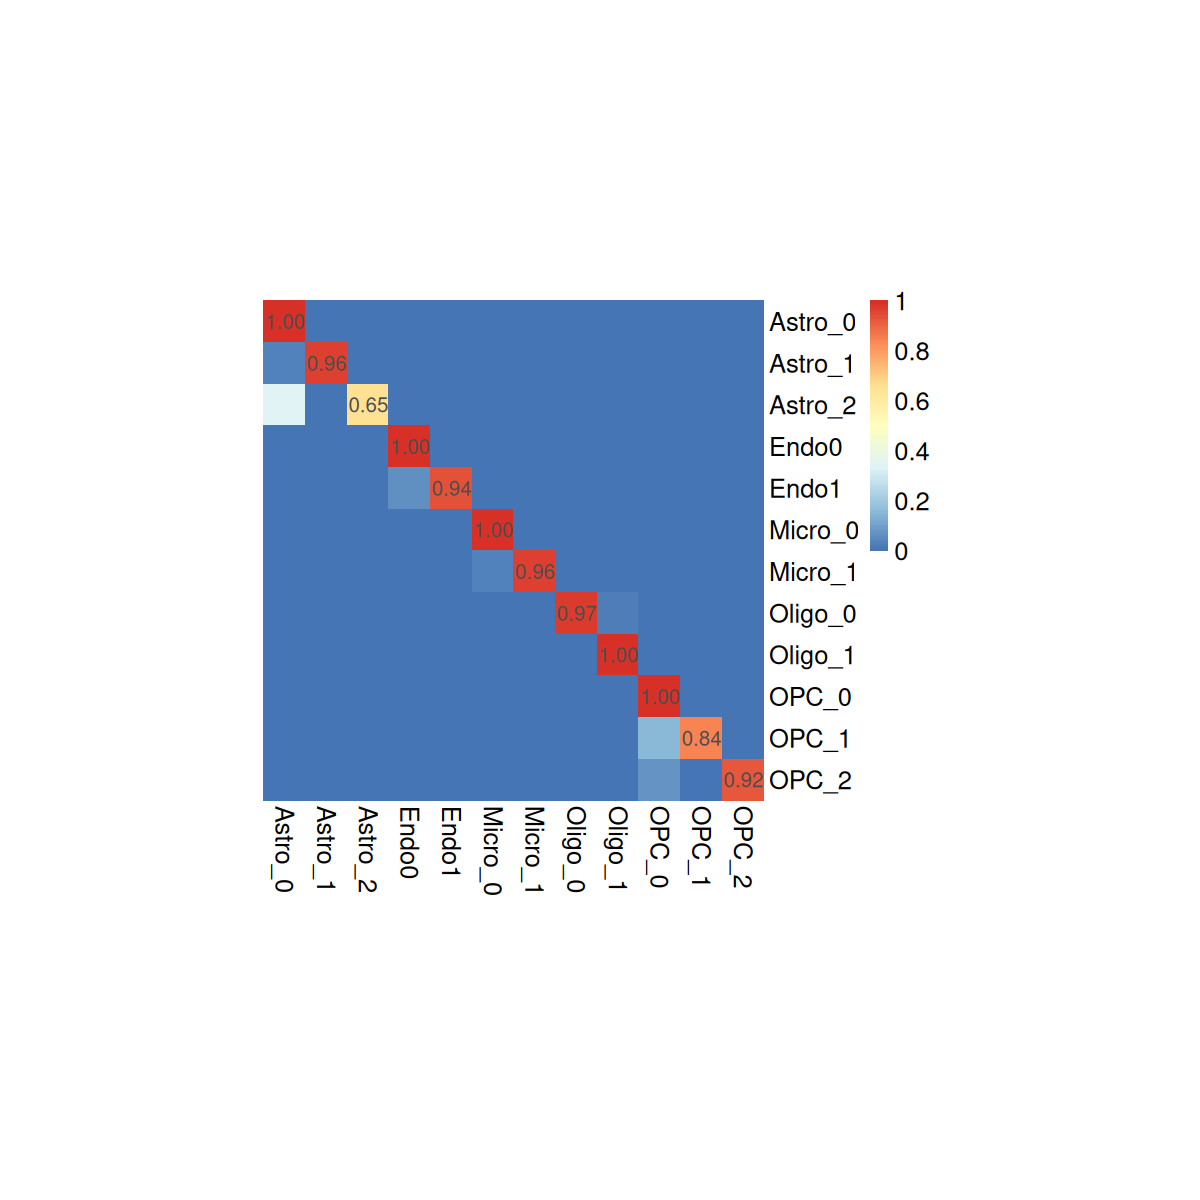

In [16]:
confusionRatio = t(apply(rf$confusion[1:12, 1:12], 1, function(x) {x/sum(x)}))

display_values <- ifelse(confusionRatio > 0.5, sprintf("%.2f", confusionRatio), "")

options(repr.plot.width=10, repr.plot.height=10)
pheatmap(
    confusionRatio,
    breaks = seq(0, 1, 0.01),
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    border_color = NA,
    cellwidth = 25,
    cellheight = 25,
    fontsize = 15,
    display_numbers = display_values,
    # file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_nonneuron_cluster_RF_confusion-2.pdf"
)

In [ ]:
confusionRatio = t(apply(rf$confusion[1:12, 1:12], 1, function(x) {x/sum(x)}))
options(repr.plot.width=10, repr.plot.height=10)
pheatmap(
    confusionRatio, 
    breaks=seq(0,1,0.01), 
    cluster_rows=F, 
    cluster_cols=F, 
    border_color=NA, 
    cellwidth=25, 
    cellheight=25, 
    fontsize=15,
    display_numbers =T,
    # file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_nonneuron_cluster_RF_confusion-2.pdf"
    )

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3034800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3034800)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor grap

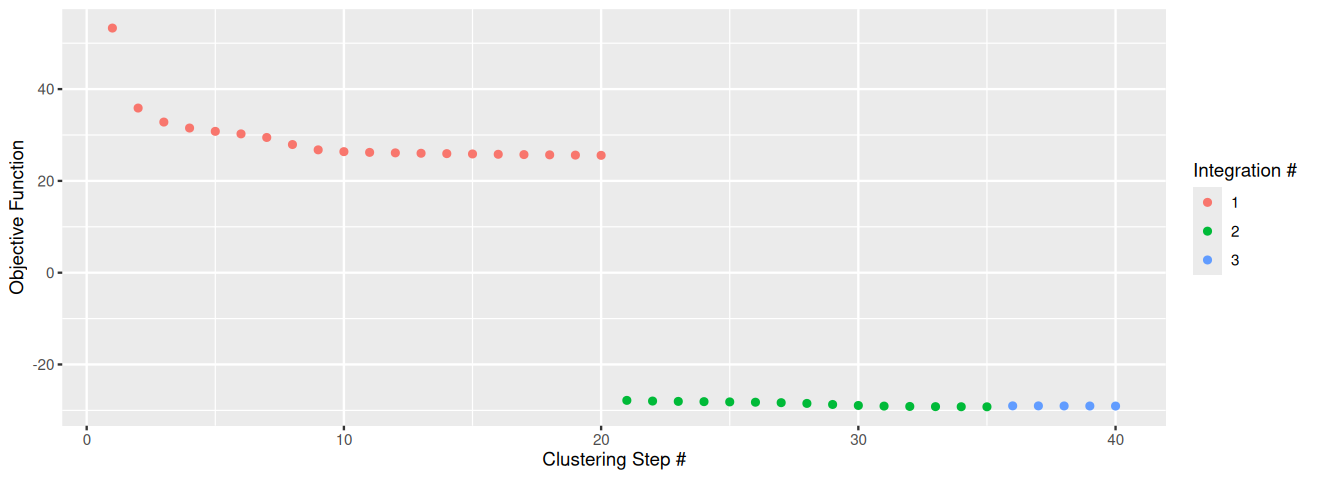

In [25]:
class_resolution = 0.1

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

nonneuron_data1 = seurat_non_1

assay = nonneuron_data1@assays$RNA$counts
meta = nonneuron_data1@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

nonneuron_data1 = CreateSeuratObject(counts = new_assay)
nonneuron_data1 = AddMetaData(nonneuron_data1, meta)

nonneuron_data1 = NormalizeData(nonneuron_data1, normalization.method = "LogNormalize", scale.factor = 10000)
nonneuron_data1 = FindVariableFeatures(nonneuron_data1, selection.method = "vst", nfeatures = 3000)
nonneuron_data1 = ScaleData(nonneuron_data1, features = rownames(nonneuron_data1))

nonneuron_data1 = nonneuron_data1 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

nonneuron_data1 = RunHarmony(
    nonneuron_data1, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

nonneuron_data1 = nonneuron_data1 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

In [ ]:
Idents(nonneuron_data1) <- 'cluster'
nonneuron_data1_sub = subset(nonneuron_data1, downsample = 500)
markers = FindAllMarkers(nonneuron_data1_sub, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")
markers

In [27]:
markers_filt = markers
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
markers_filt <- markers_filt[!markers_filt$gene %in% MTGenes, ]
markers_filt = markers_filt %>% filter(!grepl("^ENSMFAG", gene))


markers_filt = subset(markers_filt, p_val_adj < 0.01)
markers_filt = subset(markers_filt, avg_log2FC > 0.5)

table(markers_filt$cluster)


Astro_0 Astro_1 Astro_2   Endo0   Endo1 Micro_0 Micro_1   OPC_0   OPC_1   OPC_2 
   1058     922    1326    2448     667    1928     706     868     492     758 
Oligo_0 Oligo_1  VLMC_0 
   1013    1762    1625 

In [ ]:
markers_filt_top10 = markers_filt %>% 
    # filter(pct.1 > 0.2) %>% 
    group_by(cluster) %>% 
    top_n(n = 3, wt = avg_log2FC)

markers_filt_top10

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


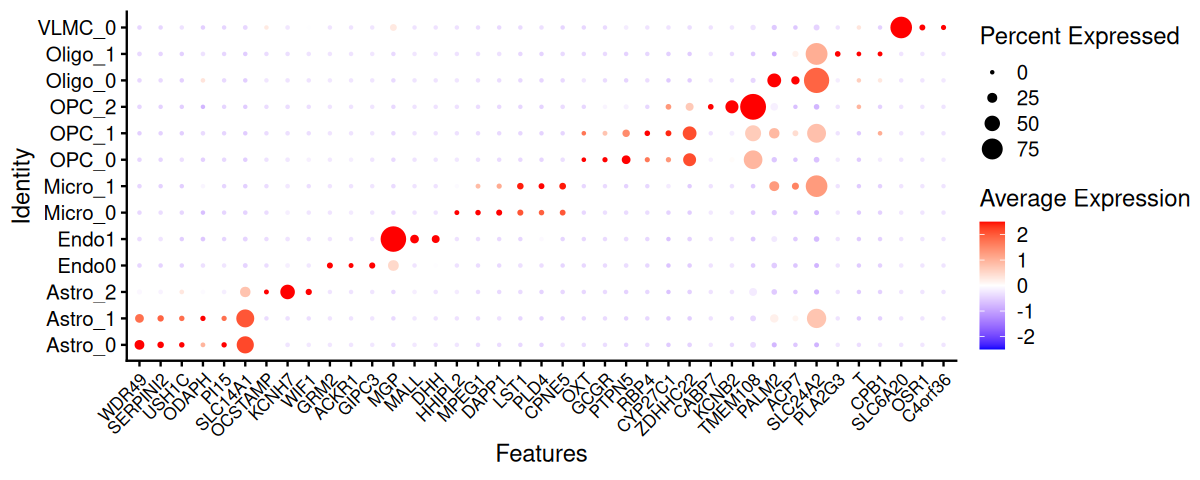

In [31]:
markers_filt_top10_ordered <- markers_filt_top10 %>%
    mutate(
        gene = trimws(as.character(gene)),
        cluster = as.character(cluster)
    ) %>%
    filter(!is.na(gene), gene != "") %>%
    left_join(
        nonneuron_data1@meta.data %>%
            dplyr::select(cluster, Class) %>%
            distinct(),
        by = "cluster"
    ) %>%
    arrange(Class, cluster, desc(avg_log2FC)) %>%
    filter(!duplicated(gene))

gene_order <- unique(markers_filt_top10_ordered$gene)

cluster_order <- markers_filt_top10_ordered %>%
    distinct(Class, cluster) %>%
    arrange(Class, cluster) %>%
    pull(cluster)

# 设置 Seurat object 中 cluster 的顺序
nonneuron_data1$cluster <- factor(
    nonneuron_data1$cluster,
    levels = cluster_order
)

options(repr.plot.width = 10, repr.plot.height = 4)

DotPlot(
    nonneuron_data1,
    features = gene_order,
    group.by = "cluster",
    dot.scale = 6
) +
    scale_color_gradient2(
        low = "blue",
        mid = "white",
        high = "red",
        midpoint = 0,
        limits = c(-2.5, 2.5)
    ) +
    theme(
        axis.text.x = element_text(
            size = 10,
            angle = 45,
            hjust = 1
        ),
        axis.text.y = element_text(size = 12)
    )

In [32]:
nonneuron_data2 = nonneuron_data1

# 将左侧 cluster 合并到右侧 cluster；请按实际 cluster 名称修改
merge_map <- c(
    "OPC_1" = "OPC_0",
    "Astro_1" = "Astro_0",
    "Micro_1" = "Micro_0"
)

nonneuron_data2$cluster <- as.character(nonneuron_data2$cluster)

idx <- nonneuron_data2$cluster %in% names(merge_map)
nonneuron_data2$cluster[idx] <- unname(merge_map[nonneuron_data2$cluster[idx]])

nonneuron_data2$cluster <- factor(nonneuron_data2$cluster)
Idents(nonneuron_data2) <- "cluster"

table(nonneuron_data2$cluster)


Astro_0 Astro_2   Endo0   Endo1 Micro_0 Oligo_0 Oligo_1   OPC_0   OPC_2  VLMC_0 
  13095     294     461     121    3932   31356    2842    7702     179     714 

In [ ]:
nonneuron_data2$cluster <- as.character(nonneuron_data2$cluster)

nonneuron_data2$cluster[nonneuron_data2$cluster == "Astro_2"] <- "Astro_1"
nonneuron_data2$cluster[nonneuron_data2$cluster == "OPC_2"] <- "OPC_1"

table(nonneuron_data2$cluster)


Astro_0 Astro_1  Endo_0  Endo_1 Micro_0 Oligo_0 Oligo_1   OPC_0   OPC_1  VLMC_0 
  13095     294     461     121    3932   31356    2842    7702     179     714 

In [ ]:
Idents(nonneuron_data2) <- 'cluster'
markers = FindAllMarkers(nonneuron_data2, only.pos = TRUE, logfc.threshold = 0.25, test.use = "MAST")
markers

In [71]:
write.csv(
    markers, 
    file = "/mnt/90-connectome/Personal/CQW/midbrain/datasets/Nonneuron_cluster_markers.csv", 
    row.names = TRUE
    ) 

In [35]:
markers_filt = markers
MTGenes <- c("ND6","COX1","ND5","ND4","ND2","ND4L","ATP8","CYTB","COX2","ND3","ATP6","ND1","COX3")
markers_filt <- markers_filt[!markers_filt$gene %in% MTGenes, ]
markers_filt = markers_filt %>% filter(!grepl("^ENSMFAG", gene))


markers_filt = subset(markers_filt, p_val_adj < 0.01)
markers_filt = subset(markers_filt, avg_log2FC > 0.5)

table(markers_filt$cluster)


Oligo_0 Astro_0 Oligo_1   OPC_0  VLMC_0 Micro_0  Endo_1 Astro_1  Endo_0   OPC_1 
   1548    3154    1678    2076    2111    3093     934    1859    3481    1106 

In [ ]:
markers_filt_top10 = markers_filt %>% 
    filter(pct.1 > 0.2) %>% 
    group_by(cluster) %>% 
    top_n(n = 3, wt = avg_log2FC)

markers_filt_top10

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


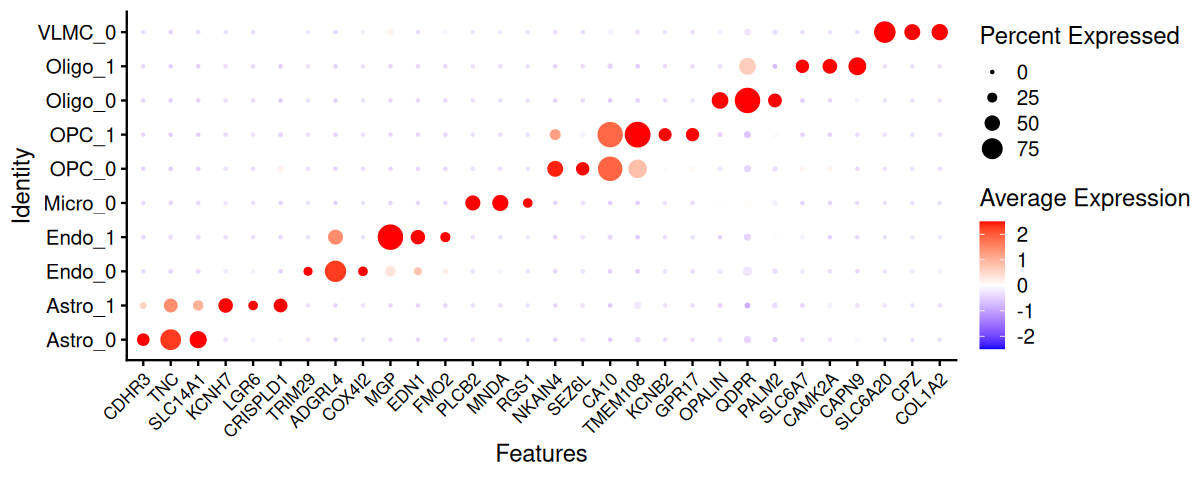

In [37]:
markers_filt_top10_ordered <- markers_filt_top10 %>%
    mutate(
        gene = trimws(as.character(gene)),
        cluster = as.character(cluster)
    ) %>%
    filter(!is.na(gene), gene != "") %>%
    left_join(
        nonneuron_data2@meta.data %>%
            dplyr::select(cluster, Class) %>%
            distinct(),
        by = "cluster"
    ) %>%
    arrange(Class, cluster, desc(avg_log2FC)) %>%
    filter(!duplicated(gene))

gene_order <- unique(markers_filt_top10_ordered$gene)

cluster_order <- markers_filt_top10_ordered %>%
    distinct(Class, cluster) %>%
    arrange(Class, cluster) %>%
    pull(cluster)

# 设置 Seurat object 中 cluster 的顺序
nonneuron_data2$cluster <- factor(
    nonneuron_data2$cluster,
    levels = cluster_order
)

options(repr.plot.width = 10, repr.plot.height = 4)

DotPlot(
    nonneuron_data2,
    features = gene_order,
    group.by = "cluster",
    dot.scale = 6
) +
    scale_color_gradient2(
        low = "blue",
        mid = "white",
        high = "red",
        midpoint = 0,
        limits = c(-2.5, 2.5)
    ) +
    theme(
        axis.text.x = element_text(
            size = 10,
            angle = 45,
            hjust = 1
        ),
        axis.text.y = element_text(size = 12)
    )

In [60]:
pdf(file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_nonneuron_cluster_DotPlot-new-5.pdf", width = 10, height = 4)

options(repr.plot.width = 10, repr.plot.height = 4)

DotPlot(
    nonneuron_data2,
    features = gene_order,
    group.by = "cluster",
    dot.scale = 6
) +
    scale_color_gradient2(
        low = "blue",
        mid = "white",
        high = "red",
        midpoint = 0,
        limits = c(-2.5, 2.5)
    ) +
    theme(
        axis.text.x = element_text(
            size = 10,
            angle = 45,
            hjust = 1
        ),
        axis.text.y = element_text(size = 12)
    )

dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


agg_record_1535344613 
                    2

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Computing nearest neighbor graph

Computing SNN

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”
Transposing data matrix

Initializing state using k-means centroids initialization

Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3034800)”
Warning message:
“Quick-TRANSfer stage steps exceeded maximum (= 3034800)”
Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor grap

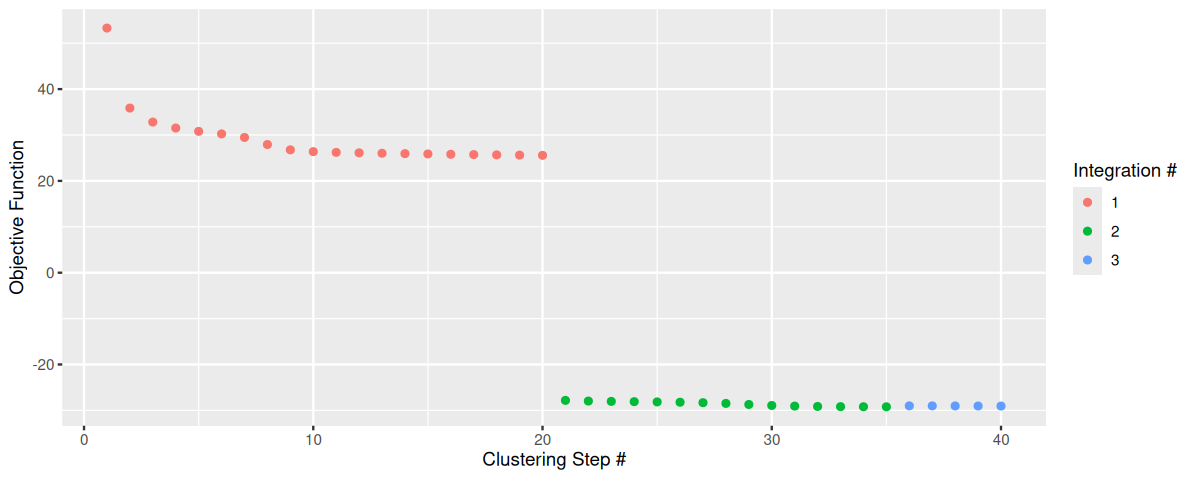

In [38]:
class_resolution = 0.1

mt_gene = c("ND6", "COX3", "COX1", "ND5", "ND4", "ND2", "ND4L", "ATP8", "CYTB", "COX2", "ND3", "ATP6", "ND1")

nonneuron_data3 = nonneuron_data2

assay = nonneuron_data3@assays$RNA$counts
meta = nonneuron_data3@meta.data
new_assay = assay[setdiff(rownames(assay), mt_gene), ]

nonneuron_data3 = CreateSeuratObject(counts = new_assay)
nonneuron_data3 = AddMetaData(nonneuron_data3, meta)

nonneuron_data3 = NormalizeData(nonneuron_data3, normalization.method = "LogNormalize", scale.factor = 10000)
nonneuron_data3 = FindVariableFeatures(nonneuron_data3, selection.method = "vst", nfeatures = 3000)
nonneuron_data3 = ScaleData(nonneuron_data3, features = rownames(nonneuron_data3))

nonneuron_data3 = nonneuron_data3 %>%
    RunPCA(npcs = 50, verbose = FALSE) %>%
    FindNeighbors(dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(dims = 1:25, umap.method = "umap-learn")

nonneuron_data3 = RunHarmony(
    nonneuron_data3, group.by.vars = "Animal", plot_convergence = TRUE,
    reduction.save = "harmony", dims.use = 1:25,
    theta = 2
)

nonneuron_data3 = nonneuron_data3 %>%
    FindNeighbors(reduction = "harmony", dims = 1:25) %>%
    FindClusters(verbose = FALSE, resolution = class_resolution, random.seed = 1234) %>%
    RunUMAP(reduction = "harmony", dims = 1:25)

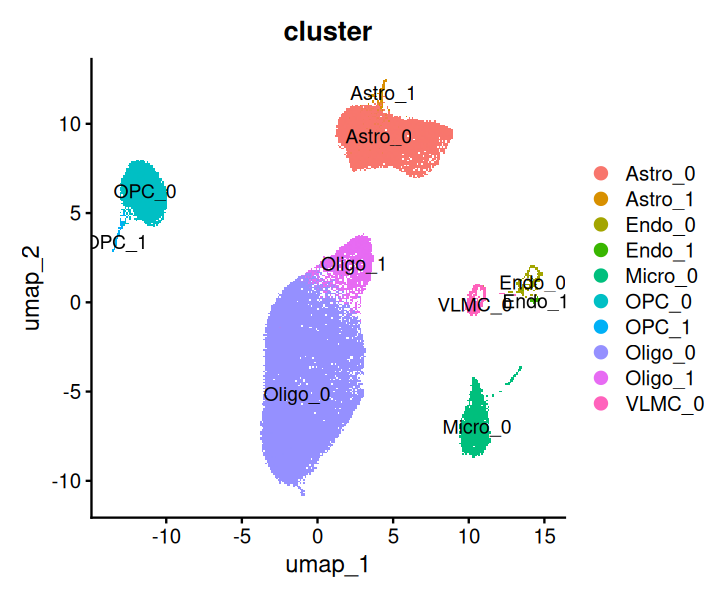

In [65]:

options(repr.plot.width = 6, repr.plot.height = 5)
DimPlot(nonneuron_data3, group.by = "cluster",label = TRUE,raster = TRUE,raster.dpi = c(300, 300))

In [66]:
pdf('/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_nonneuron_cluster_UMAP-new-6.pdf', width = 6, height = 5)

options(repr.plot.width = 6, repr.plot.height = 5)

DimPlot(nonneuron_data3, group.by = "cluster",label = TRUE,raster = TRUE,raster.dpi = c(300, 300))
dev.off()

agg_record_927424432 
                   2

In [67]:
pdf(file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_noneuron_cluster_marker_umap-11.pdf", width = 18, height = 6)

options(repr.plot.width=18, repr.plot.height=6)

FeaturePlot(
nonneuron_data3, 
features = c(
    "QDPR","CAPN9","CDHR3"
    ), 
ncol = 3, 
raster = TRUE,
raster.dpi = c(300, 300),
cols = c("grey", "blue")
)


dev.off()


agg_record_793672332 
                   2

In [42]:
sampleRatio = 0.8
maxCell = 500
sampleDf = nonneuron_data3@meta.data[, c("cluster"), drop=F]
sampleList = split(sampleDf, sampleDf$cluster)
sampleList = lapply(sampleList, function(x) {
    sampleSize = as.integer(nrow(x)*0.8)
    if (sampleSize > maxCell) {
        sampleSize = maxCell
    }
    sampleIdx = 1:nrow(x)
    sampleIdx = sample(1:nrow(x), size=sampleSize, replace=F)
    return(x[sampleIdx,,drop=F])
})
sampleDf = Reduce(rbind, sampleList)
str(sampleDf)
table(sampleDf$cluster )

trainSeurat = nonneuron_data3[,rownames(sampleDf)]
table(trainSeurat$cluster)

'data.frame':	3842 obs. of  1 variable:
 $ cluster: Factor w/ 10 levels "Astro_0","Astro_1",..: 1 1 1 1 1 1 1 1 1 1 ...



Astro_0 Astro_1  Endo_0  Endo_1 Micro_0   OPC_0   OPC_1 Oligo_0 Oligo_1  VLMC_0 
    500     235     368      96     500     500     143     500     500     500 


Astro_0 Astro_1  Endo_0  Endo_1 Micro_0   OPC_0   OPC_1 Oligo_0 Oligo_1  VLMC_0 
    500     235     368      96     500     500     143     500     500     500 

In [43]:
Idents(trainSeurat) = "cluster"
classMarker = FindAllMarkers(trainSeurat)
classMarker = subset(classMarker, p_val_adj < 0.01 & avg_log2FC > 1.0)
table(classMarker$cluster)

Calculating cluster Astro_0

Calculating cluster Astro_1

Calculating cluster Endo_0

Calculating cluster Endo_1

Calculating cluster Micro_0

Calculating cluster OPC_0

Calculating cluster OPC_1

Calculating cluster Oligo_0

Calculating cluster Oligo_1

Calculating cluster VLMC_0




Astro_0 Astro_1  Endo_0  Endo_1 Micro_0   OPC_0   OPC_1 Oligo_0 Oligo_1  VLMC_0 
   1096     962    2127     924    1022     846     622     528    1107     709 

In [45]:
trainDf = as.data.frame(t(as.matrix(trainSeurat@assays$RNA$data[unique(classMarker$gene), ])))
trainDf$cluster = trainSeurat$cluster
# trainDf = subset(trainDf, cluster != "Uncertain")
trainDf$cluster = factor(trainDf$cluster)
# We need to modify the name of the columns
colnames(trainDf) = paste0("col_", colnames(trainDf))
colnames(trainDf) = gsub("-", "_", colnames(trainDf))
colnames(trainDf) = gsub(" ", "_", colnames(trainDf))

rf = randomForest(col_cluster~., data=trainDf, ntree=300)

 num [1:10, 1:11] 500 92 0 0 0 0 0 0 0 0 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:10] "Astro_0" "Astro_1" "Endo_0" "Endo_1" ...
  ..$ : chr [1:11] "Astro_0" "Astro_1" "Endo_0" "Endo_1" ...


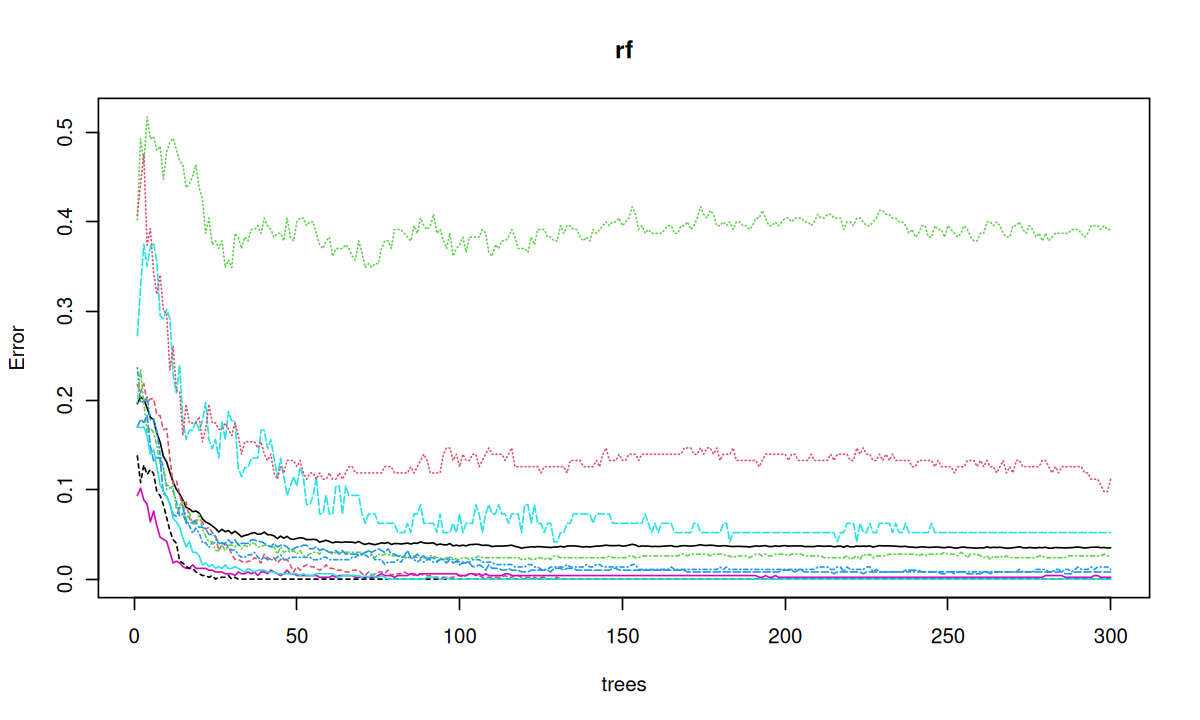

In [46]:
str(rf$confusion)
options(repr.plot.width=10, repr.plot.height=6)
plot(rf)


In [49]:
confusionRatio = t(apply(rf$confusion[1:10, 1:10], 1, function(x) {x/sum(x)}))

display_values <- ifelse(confusionRatio > 0.5, sprintf("%.2f", confusionRatio), "")

options(repr.plot.width=7, repr.plot.height=7)
pheatmap(
    confusionRatio,
    breaks = seq(0, 1, 0.01),
    cluster_rows = FALSE,
    cluster_cols = FALSE,
    border_color = NA,
    cellwidth = 25,
    cellheight = 25,
    fontsize = 15,
    display_numbers = display_values,
    file = "/mnt/90-connectome/Personal/CQW/midbrain/figure/VTA_nonneuron_cluster_RF_confusion-3.pdf"
)

In [68]:
saveRDS(nonneuron_data3, '/mnt/90-connectome/Personal/CQW/midbrain/datasets/20260904_VTA_nonneuron_cluster.rds')